# Peripheral Insecurity in Nigeria — Reproducibility Notebook

**Purpose:** reproduce the analytical workflow supporting the frozen manuscript. The notebook uses the project folder structure and does not depend on personal computer paths or previous execution history.

The manuscript was developed using Excel for initial data cleaning/validation and Python for reproduction, integration, statistical analysis, diagnostics, and output generation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import scipy.stats as stats
import statsmodels
import statsmodels.api as sm
import geopandas as gpd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Resolve the project root from the standard repository structure.
# The notebook is expected to be opened from the notebooks/ directory.
PROJECT_ROOT = Path.cwd().parent
if not (PROJECT_ROOT / "data" / "processed").exists():
    raise FileNotFoundError(
        "Project root could not be resolved. Open this notebook from the project's notebooks/ directory."
    )

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
TABLES_DIR = OUTPUTS_DIR / "tables"
MODELS_DIR = OUTPUTS_DIR / "models"

# Compatibility aliases used by retained analysis cells.
project_root = PROJECT_ROOT
processed = PROCESSED_DIR
figures_dir = FIGURES_DIR
tables_dir = TABLES_DIR

for folder in [FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Python environment ready")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)
print("geopandas:", gpd.__version__)

Project root: C:\Users\user\Desktop\RESEARCH MASTER PACKAGE\peripheral-insecurity-nigeria-Jupyter-Notebook
Python environment ready
pandas: 2.3.3
numpy: 2.3.5
scipy: 1.16.3
statsmodels: 0.14.5
geopandas: 1.1.4


## 1. Load and validate the spreadsheet-based analytical datasets

In [2]:
import pandas as pd

processed = project_root / "data" / "processed"

files = [
    "ACLED Data_2025_Cleaning.xlsx",
    "NBS_Security_Analysis.xlsx",
    "WorldPop_State_Settlement_Dataset.xlsx"
]

for filename in files:
    path = processed / filename
    excel_file = pd.ExcelFile(path)

    print("\n" + "=" * 70)
    print(filename)
    print("=" * 70)
    print("Sheets:")
    
    for sheet in excel_file.sheet_names:
        print("  -", sheet)


ACLED Data_2025_Cleaning.xlsx
Sheets:
  - ACLED Data_2026-09-02_event_dat
  - 01_State_Security_Profile
  - Sheet1
  - 02_Event_Type_Profile
  - Acled_Clean_2025
  - 04_Rate_Analysis
  - Research Log
  - 03_Population_Denominators

NBS_Security_Analysis.xlsx
Sheets:
  - 07_NBS_Security
  - NBS_All_Shocks
  - Variable_Map
  - QC_Methods
  - ACLED_2025_State
  - Correlation_Results
  - Sensitivity_Borno
  - Combined_Analysis

WorldPop_State_Settlement_Dataset.xlsx
Sheets:
  - WorldPop_State
  - Settlement_Analysis
  - Combined_Analysis
  - Outlier_Check
  - Sensitivity_Borno_Zamfara
  - Settlement_Correlations
  - Settlement_Sensitivity_Borno
  - Settlement_Top_Bottom_5
  - Analysis_Summary
  - Methodology


## 2. Construct the master analytical dataset

In [3]:
# Load the two main analytical datasets

nbs_path = processed / "NBS_Security_Analysis.xlsx"
worldpop_path = processed / "WorldPop_State_Settlement_Dataset.xlsx"

nbs_state = pd.read_excel(
    nbs_path,
    sheet_name="ACLED_2025_State"
)

settlement = pd.read_excel(
    worldpop_path,
    sheet_name="Settlement_Analysis"
)

print("NBS state dataset:")
print(nbs_state.shape)
display(nbs_state.head())

print("\nWorldPop settlement dataset:")
print(settlement.shape)
display(settlement.head())

NBS state dataset:
(37, 10)


,State,Population_2022,ACLED_Events_2025,ACLED_Fatalities_2025,Events_per_100k,Fatalities_per_100k,MPI_%,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Abia,4143100,54,94,1.303372,2.268833,29.8,NaN,37.0,37.0
1,Adamawa,4902100,96,131,1.958344,2.672324,68.7,NaN,37.0,37.0
2,Akwa Ibom,4979400,39,16,0.783227,0.321324,71.3,NaN,37.0,NaN
3,Anambra,5953500,119,160,1.998824,2.687495,32.1,NaN,37.0,NaN
4,Bauchi,8308800,48,61,0.577701,0.734161,73.5,NaN,15462200.0,NaN



WorldPop settlement dataset:
(37, 15)


,State,MPI_%,Urban_Cluster_Footprint_%,Rural_Cluster_Footprint_%,Urban_Cluster_Pop_Allocated,Urban_Cluster_Area_km2,Rural_Cluster_Pop_Allocated,Rural_Cluster_Area_km2,ACLED_Events_2025,ACLED_Fatalities_2025,Events_per_100k,Fatalities_per_100k,Urban_Footprint_Rank,Event_Rate_Rank,Fatality_Rate_Rank
0,Abia,29.8,44.095346,1.436251,5.361633e+06,2156.994628,69486.182067,70.256532,54,94,1.303372,2.268833,32,12,19
1,Adamawa,68.7,4.731767,2.329002,3.184725e+06,1801.057343,517820.057919,886.490601,96,131,1.958344,2.672324,8,18,22
2,Akwa Ibom,71.3,50.348935,1.385566,8.680813e+06,3415.726996,64453.987150,93.998320,39,16,0.783227,0.321324,35,6,3
3,Anambra,32.1,41.886885,1.540058,5.119963e+06,2026.128814,53166.509718,74.494806,119,160,1.998824,2.687495,31,19,23
4,Bauchi,73.5,7.319323,2.820388,3.526252e+06,3573.341052,794908.913699,1376.931776,48,61,0.577701,0.734161,12,3,8


In [4]:
# ---------------------------------------------------------
# STEP 2: Validate state identifiers and data completeness
# ---------------------------------------------------------

# 1. Check the state names in both datasets
nbs_states = set(nbs_state["State"].dropna().str.strip())
worldpop_states = set(settlement["State"].dropna().str.strip())

print("Number of states in NBS:", len(nbs_states))
print("Number of states in WorldPop:", len(worldpop_states))

# 2. Check whether any states are missing from either dataset
print("\nStates in NBS but not WorldPop:")
print(sorted(nbs_states - worldpop_states))

print("\nStates in WorldPop but not NBS:")
print(sorted(worldpop_states - nbs_states))

# 3. Check for duplicate state names
print("\nDuplicate states in NBS:")
print(nbs_state[nbs_state["State"].duplicated(keep=False)])

print("\nDuplicate states in WorldPop:")
print(settlement[settlement["State"].duplicated(keep=False)])

# 4. Check missing values in the key analytical variables
nbs_variables = [
    "State",
    "Population_2022",
    "ACLED_Events_2025",
    "ACLED_Fatalities_2025",
    "Events_per_100k",
    "Fatalities_per_100k",
    "MPI_%"
]

worldpop_variables = [
    "State",
    "Urban_Cluster_Footprint_%",
    "Rural_Cluster_Footprint_%"
]

print("\nMissing values — NBS variables:")
print(nbs_state[nbs_variables].isna().sum())

print("\nMissing values — WorldPop variables:")
print(settlement[worldpop_variables].isna().sum())

Number of states in NBS: 37
Number of states in WorldPop: 37

States in NBS but not WorldPop:
['NASARAWA']

States in WorldPop but not NBS:
['Nasarawa']

Duplicate states in NBS:
Empty DataFrame
Columns: [State, Population_2022, ACLED_Events_2025, ACLED_Fatalities_2025, Events_per_100k, Fatalities_per_100k, MPI_%, Unnamed: 7, Unnamed: 8, Unnamed: 9]
Index: []

Duplicate states in WorldPop:
Empty DataFrame
Columns: [State, MPI_%, Urban_Cluster_Footprint_%, Rural_Cluster_Footprint_%, Urban_Cluster_Pop_Allocated, Urban_Cluster_Area_km2, Rural_Cluster_Pop_Allocated, Rural_Cluster_Area_km2, ACLED_Events_2025, ACLED_Fatalities_2025, Events_per_100k, Fatalities_per_100k, Urban_Footprint_Rank, Event_Rate_Rank, Fatality_Rate_Rank]
Index: []

Missing values — NBS variables:
State                    0
Population_2022          0
ACLED_Events_2025        0
ACLED_Fatalities_2025    0
Events_per_100k          0
Fatalities_per_100k      0
MPI_%                    0
dtype: int64

Missing values — World

In [5]:
# ---------------------------------------------------------
# STEP 3: Standardize state names and create master dataset
# ---------------------------------------------------------

# Make copies so the original imported datasets remain unchanged
nbs = nbs_state.copy()
wp = settlement.copy()

# Standardize state names
nbs["State"] = nbs["State"].str.strip().str.upper()
wp["State"] = wp["State"].str.strip().str.upper()

# Select only the variables needed for the main analysis
nbs_analysis = nbs[
    [
        "State",
        "Population_2022",
        "ACLED_Events_2025",
        "ACLED_Fatalities_2025",
        "Events_per_100k",
        "Fatalities_per_100k",
        "MPI_%"
    ]
].copy()

wp_analysis = wp[
    [
        "State",
        "Urban_Cluster_Footprint_%",
        "Rural_Cluster_Footprint_%"
    ]
].copy()

# Merge the two datasets using State as the key
master = pd.merge(
    nbs_analysis,
    wp_analysis,
    on="State",
    how="inner",
    validate="one_to_one"
)

# Sort alphabetically by state
master = master.sort_values("State").reset_index(drop=True)

# Display the resulting dataset
print("Master analytical dataset shape:", master.shape)

display(master)

# Final integrity checks
print("\nNumber of unique states:", master["State"].nunique())

print("\nMissing values:")
print(master.isna().sum())

Master analytical dataset shape: (37, 9)


,State,Population_2022,ACLED_Events_2025,ACLED_Fatalities_2025,Events_per_100k,Fatalities_per_100k,MPI_%,Urban_Cluster_Footprint_%,Rural_Cluster_Footprint_%
0,ABIA,4143100,54,94,1.303372,2.268833,29.8,44.095346,1.436251
1,ADAMAWA,4902100,96,131,1.958344,2.672324,68.7,4.731767,2.329002
2,AKWA IBOM,4979400,39,16,0.783227,0.321324,71.3,50.348935,1.385566
3,ANAMBRA,5953500,119,160,1.998824,2.687495,32.1,41.886885,1.540058
4,BAUCHI,8308800,48,61,0.577701,0.734161,73.5,7.319323,2.820388
5,BAYELSA,2537400,38,27,1.497596,1.064081,83.3,6.235089,2.424621
6,BENUE,6141300,364,882,5.927084,14.361780,75.0,15.712008,2.632568
7,BORNO,6111500,836,3960,13.679130,64.795877,72.5,1.616100,1.639249
8,CROSS RIVER,4406200,48,34,1.089374,0.771640,75.4,9.125946,2.015127
9,DELTA,5636100,151,114,2.679158,2.022675,47.8,13.106076,2.008491



Number of unique states: 37

Missing values:
State                        0
Population_2022              0
ACLED_Events_2025            0
ACLED_Fatalities_2025        0
Events_per_100k              0
Fatalities_per_100k          0
MPI_%                        0
Urban_Cluster_Footprint_%    0
Rural_Cluster_Footprint_%    0
dtype: int64


In [6]:
# ---------------------------------------------------------
# STEP 4: Save the validated master analytical dataset
# ---------------------------------------------------------

master_path = processed / "master_analytical_dataset.csv"

master.to_csv(
    master_path,
    index=False
)

print("Master dataset saved to:")
print(master_path)

print("\nDataset shape:", master.shape)

Master dataset saved to:
C:\Users\user\Desktop\RESEARCH MASTER PACKAGE\peripheral-insecurity-nigeria-Jupyter-Notebook\data\processed\master_analytical_dataset.csv

Dataset shape: (37, 9)


In [7]:
master_path = processed / "master_analytical_dataset.csv"

master = pd.read_csv(master_path)

print("Master dataset restored.")
print("Shape:", master.shape)
print("States:", master["State"].nunique())

Master dataset restored.
Shape: (37, 9)
States: 37


In [8]:
# ---------------------------------------------------------
# STEP 5: Descriptive statistics
# ---------------------------------------------------------

analysis_vars = [
    "MPI_%",
    "Urban_Cluster_Footprint_%",
    "Events_per_100k",
    "Fatalities_per_100k"
]

descriptive_stats = master[analysis_vars].describe().T

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
MPI_%,37.0,62.640541,19.232849,27.200000,48.300000,66.300000,75.400000,95.500000
Urban_Cluster_Footprint_%,37.0,18.110328,18.112349,1.102906,6.178226,9.355575,20.972456,63.887778
Events_per_100k,37.0,3.806030,4.465747,0.226694,1.150225,1.998824,4.499866,21.582241
Fatalities_per_100k,37.0,7.160744,13.282805,0.055676,0.756015,2.268833,5.823253,64.795877


In [9]:
# ---------------------------------------------------------
# STEP 6: Distribution and skewness diagnostics
# ---------------------------------------------------------

from scipy.stats import skew

skewness = master[analysis_vars].apply(
    lambda x: skew(x, bias=False)
)

skewness_df = pd.DataFrame({
    "Variable": skewness.index,
    "Skewness": skewness.values
})

skewness_df

,Variable,Skewness
0,MPI_%,-0.405478
1,Urban_Cluster_Footprint_%,1.276509
2,Events_per_100k,2.345093
3,Fatalities_per_100k,3.223019


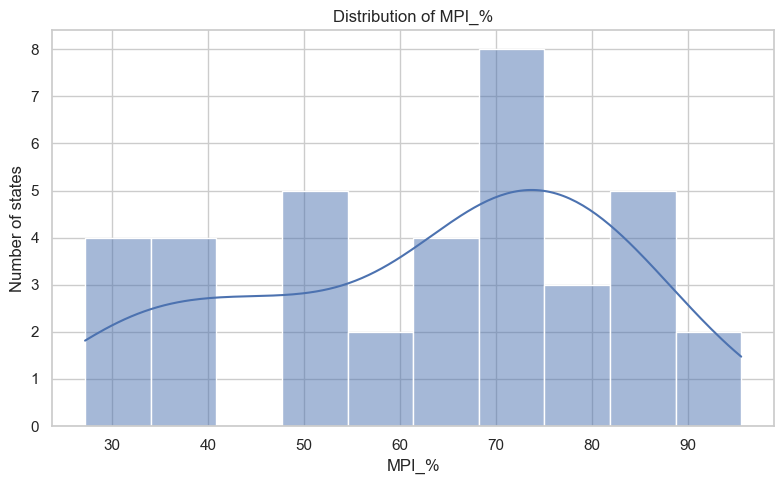

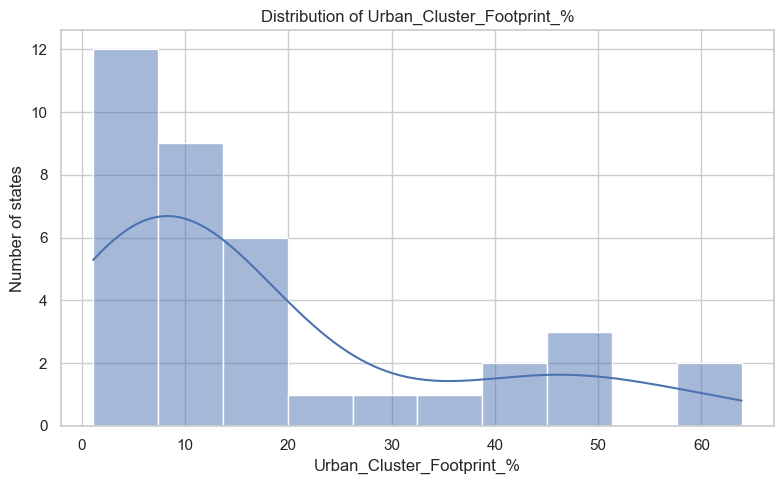

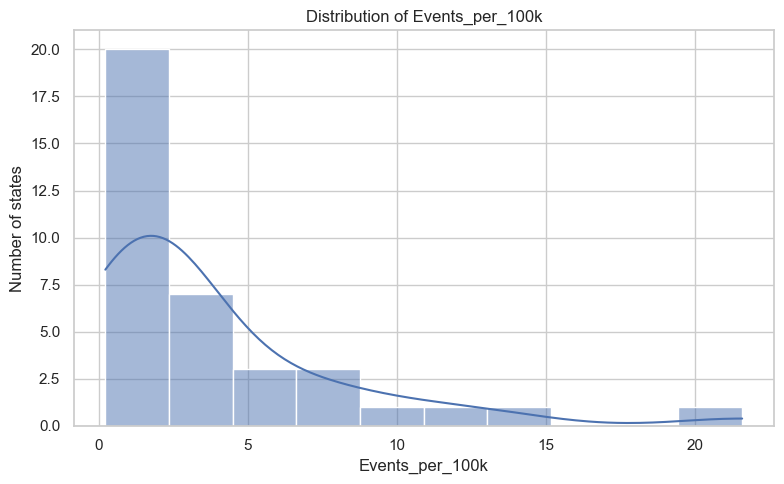

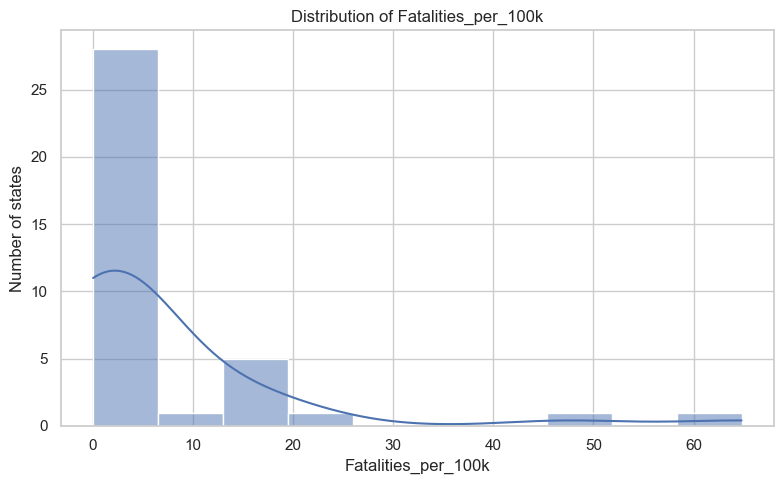

In [10]:
# ---------------------------------------------------------
# STEP 7: Distribution visualizations
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean academic plotting context
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# Create one figure for each analytical variable
for variable in analysis_vars:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=master,
        x=variable,
        kde=True,
        bins=10
    )
    
    plt.title(f"Distribution of {variable}")
    plt.xlabel(variable)
    plt.ylabel("Number of states")
    plt.tight_layout()
    plt.show()

In [11]:
# ---------------------------------------------------------
# STEP 7B: Automated distribution summary
# ---------------------------------------------------------

for variable in analysis_vars:
    values = master[variable]

    print("\n" + "=" * 60)
    print(variable)
    print("=" * 60)

    print(f"Minimum: {values.min():.2f}")
    print(f"Median:  {values.median():.2f}")
    print(f"Mean:    {values.mean():.2f}")
    print(f"Maximum: {values.max():.2f}")
    print(f"Skewness: {values.skew():.2f}")

    # Compare mean and median
    if values.mean() > values.median():
        print("Pattern: Mean is above the median.")
    elif values.mean() < values.median():
        print("Pattern: Mean is below the median.")
    else:
        print("Pattern: Mean and median are approximately equal.")


MPI_%
Minimum: 27.20
Median:  66.30
Mean:    62.64
Maximum: 95.50
Skewness: -0.41
Pattern: Mean is below the median.

Urban_Cluster_Footprint_%
Minimum: 1.10
Median:  9.36
Mean:    18.11
Maximum: 63.89
Skewness: 1.28
Pattern: Mean is above the median.

Events_per_100k
Minimum: 0.23
Median:  2.00
Mean:    3.81
Maximum: 21.58
Skewness: 2.35
Pattern: Mean is above the median.

Fatalities_per_100k
Minimum: 0.06
Median:  2.27
Mean:    7.16
Maximum: 64.80
Skewness: 3.22
Pattern: Mean is above the median.


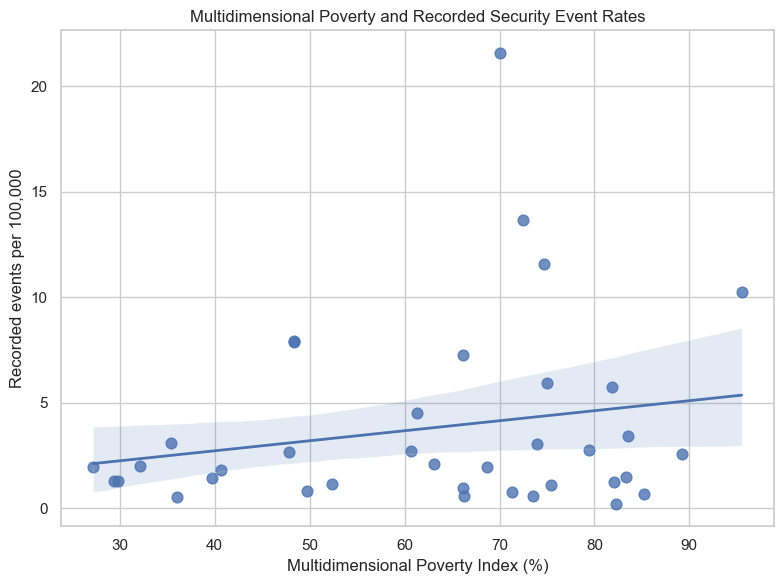

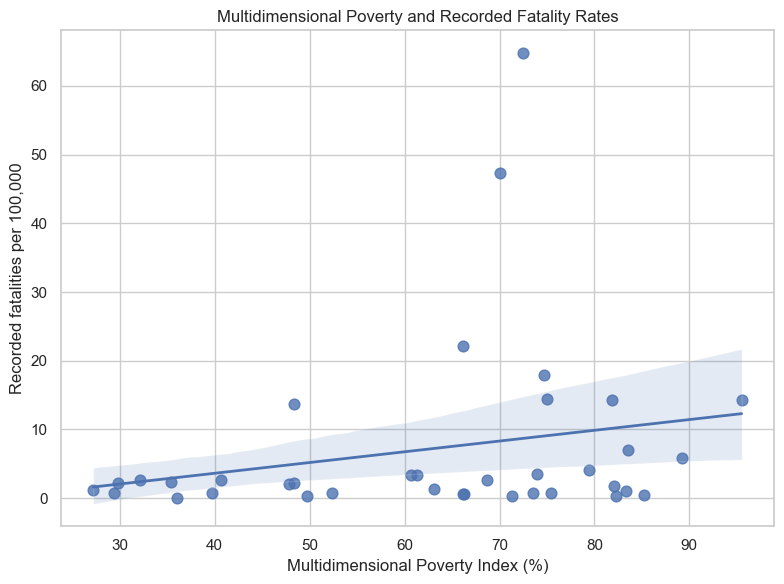

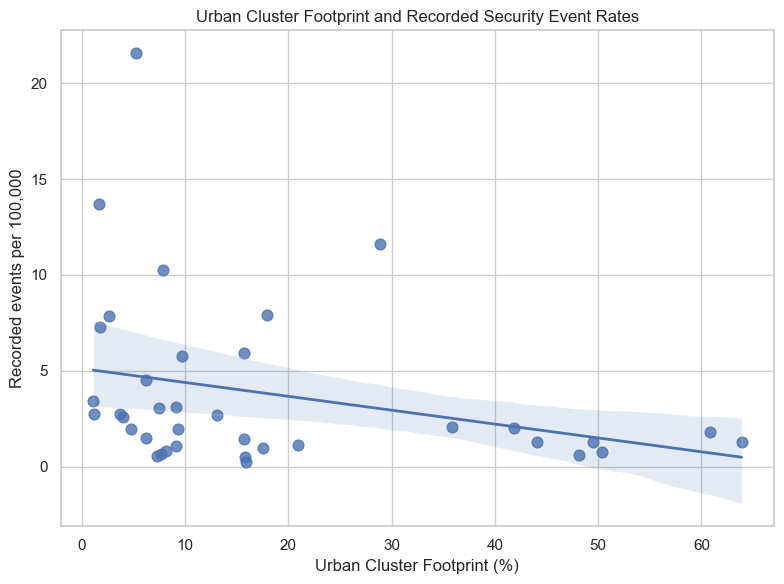

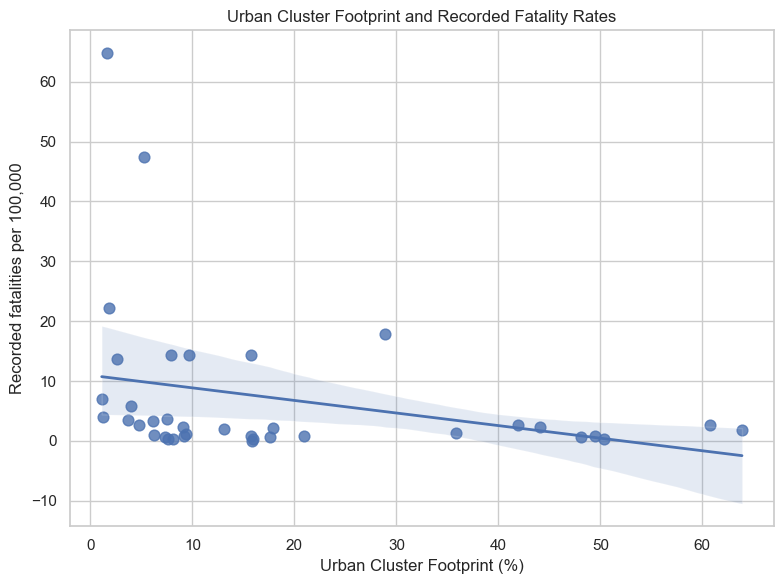

In [12]:
# ---------------------------------------------------------
# STEP 8: Core relationship visualizations
# ---------------------------------------------------------

# MPI vs event rate
plt.figure(figsize=(8, 6))

sns.regplot(
    data=master,
    x="MPI_%",
    y="Events_per_100k",
    scatter_kws={"s": 60},
    line_kws={"linewidth": 2}
)

plt.title("Multidimensional Poverty and Recorded Security Event Rates")
plt.xlabel("Multidimensional Poverty Index (%)")
plt.ylabel("Recorded events per 100,000")
plt.tight_layout()
plt.show()


# MPI vs fatality rate
plt.figure(figsize=(8, 6))

sns.regplot(
    data=master,
    x="MPI_%",
    y="Fatalities_per_100k",
    scatter_kws={"s": 60},
    line_kws={"linewidth": 2}
)

plt.title("Multidimensional Poverty and Recorded Fatality Rates")
plt.xlabel("Multidimensional Poverty Index (%)")
plt.ylabel("Recorded fatalities per 100,000")
plt.tight_layout()
plt.show()


# Urban footprint vs event rate
plt.figure(figsize=(8, 6))

sns.regplot(
    data=master,
    x="Urban_Cluster_Footprint_%",
    y="Events_per_100k",
    scatter_kws={"s": 60},
    line_kws={"linewidth": 2}
)

plt.title("Urban Cluster Footprint and Recorded Security Event Rates")
plt.xlabel("Urban Cluster Footprint (%)")
plt.ylabel("Recorded events per 100,000")
plt.tight_layout()
plt.show()


# Urban footprint vs fatality rate
plt.figure(figsize=(8, 6))

sns.regplot(
    data=master,
    x="Urban_Cluster_Footprint_%",
    y="Fatalities_per_100k",
    scatter_kws={"s": 60},
    line_kws={"linewidth": 2}
)

plt.title("Urban Cluster Footprint and Recorded Fatality Rates")
plt.xlabel("Urban Cluster Footprint (%)")
plt.ylabel("Recorded fatalities per 100,000")
plt.tight_layout()
plt.show()

In [13]:
    # ---------------------------------------------------------
# STEP 9: Pearson and Spearman correlation analysis
# ---------------------------------------------------------

from scipy.stats import pearsonr, spearmanr

relationships = [
    ("MPI_%", "Events_per_100k"),
    ("MPI_%", "Fatalities_per_100k"),
    ("Urban_Cluster_Footprint_%", "Events_per_100k"),
    ("Urban_Cluster_Footprint_%", "Fatalities_per_100k")
]

correlation_results = []

for x, y in relationships:
    
    # Pearson
    pearson_r, pearson_p = pearsonr(master[x], master[y])
    
    # Spearman
    spearman_r, spearman_p = spearmanr(master[x], master[y])
    
    correlation_results.append({
        "X": x,
        "Y": y,
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_r": spearman_r,
        "Spearman_p": spearman_p
    })

correlations = pd.DataFrame(correlation_results)

correlations

,X,Y,Pearson_r,Pearson_p,Spearman_r,Spearman_p
0,MPI_%,Events_per_100k,0.204463,0.224791,0.091998,0.588133
1,MPI_%,Fatalities_per_100k,0.226277,0.178080,0.227030,0.176601
2,Urban_Cluster_Footprint_%,Events_per_100k,-0.293398,0.077996,-0.440019,0.006425
3,Urban_Cluster_Footprint_%,Fatalities_per_100k,-0.286440,0.085656,-0.475818,0.002915


## 3. Regression models and diagnostics

In [14]:
import statsmodels.api as sm

# Define predictors and outcomes
X = master[["MPI_%", "Urban_Cluster_Footprint_%"]]

# Add intercept
X = sm.add_constant(X)

# Event-rate model
y_event = master["Events_per_100k"]

event_model = sm.OLS(y_event, X).fit()

print(event_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Events_per_100k   R-squared:                       0.101
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     1.901
Date:                Sat, 26 Sep 2026   Prob (F-statistic):              0.165
Time:                        17:49:58   Log-Likelihood:                -105.40
No. Observations:                  37   AIC:                             216.8
Df Residuals:                      34   BIC:                             221.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [15]:
# Fatality-rate model
y_fatality = master["Fatalities_per_100k"]

fatality_model = sm.OLS(y_fatality, X).fit()

print(fatality_model.summary())

                             OLS Regression Results                            
Dep. Variable:     Fatalities_per_100k   R-squared:                       0.103
Model:                             OLS   Adj. R-squared:                  0.051
Method:                  Least Squares   F-statistic:                     1.957
Date:                 Sat, 26 Sep 2026   Prob (F-statistic):              0.157
Time:                         17:49:58   Log-Likelihood:                -145.68
No. Observations:                   37   AIC:                             297.4
Df Residuals:                       34   BIC:                             302.2
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

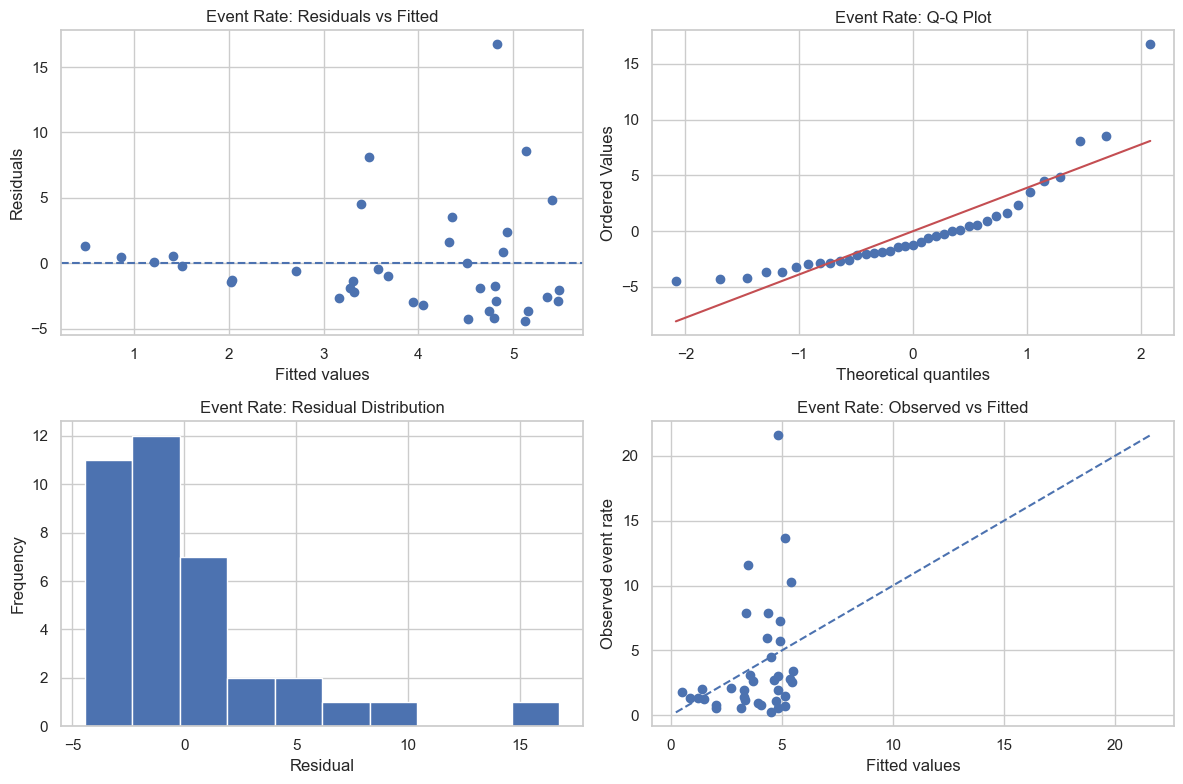

In [16]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Diagnostic plots for the event-rate model
fig = plt.figure(figsize=(12, 8))

# 1. Residuals vs fitted
ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(event_model.fittedvalues, event_model.resid)
ax1.axhline(0, linestyle="--")
ax1.set_xlabel("Fitted values")
ax1.set_ylabel("Residuals")
ax1.set_title("Event Rate: Residuals vs Fitted")

# 2. Q-Q plot
ax2 = fig.add_subplot(2, 2, 2)
stats.probplot(event_model.resid, dist="norm", plot=ax2)
ax2.set_title("Event Rate: Q-Q Plot")

# 3. Residual histogram
ax3 = fig.add_subplot(2, 2, 3)
ax3.hist(event_model.resid, bins=10)
ax3.set_xlabel("Residual")
ax3.set_ylabel("Frequency")
ax3.set_title("Event Rate: Residual Distribution")

# 4. Actual vs fitted
ax4 = fig.add_subplot(2, 2, 4)
ax4.scatter(event_model.fittedvalues, master["Events_per_100k"])
ax4.plot(
    [master["Events_per_100k"].min(), master["Events_per_100k"].max()],
    [master["Events_per_100k"].min(), master["Events_per_100k"].max()],
    linestyle="--"
)
ax4.set_xlabel("Fitted values")
ax4.set_ylabel("Observed event rate")
ax4.set_title("Event Rate: Observed vs Fitted")

plt.tight_layout()
plt.show()

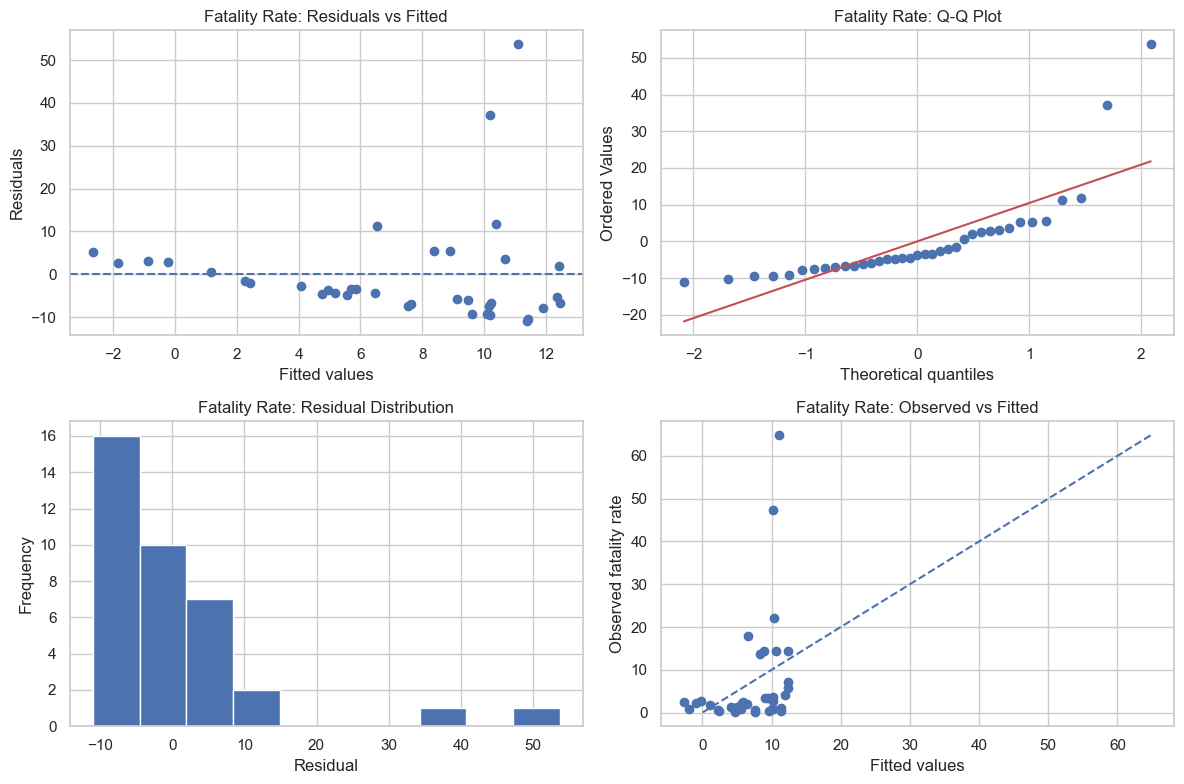

In [17]:
fig = plt.figure(figsize=(12, 8))

# 1. Residuals vs fitted
ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(fatality_model.fittedvalues, fatality_model.resid)
ax1.axhline(0, linestyle="--")
ax1.set_xlabel("Fitted values")
ax1.set_ylabel("Residuals")
ax1.set_title("Fatality Rate: Residuals vs Fitted")

# 2. Q-Q plot
ax2 = fig.add_subplot(2, 2, 2)
stats.probplot(fatality_model.resid, dist="norm", plot=ax2)
ax2.set_title("Fatality Rate: Q-Q Plot")

# 3. Residual histogram
ax3 = fig.add_subplot(2, 2, 3)
ax3.hist(fatality_model.resid, bins=10)
ax3.set_xlabel("Residual")
ax3.set_ylabel("Frequency")
ax3.set_title("Fatality Rate: Residual Distribution")

# 4. Actual vs fitted
ax4 = fig.add_subplot(2, 2, 4)
ax4.scatter(fatality_model.fittedvalues, master["Fatalities_per_100k"])
ax4.plot(
    [master["Fatalities_per_100k"].min(), master["Fatalities_per_100k"].max()],
    [master["Fatalities_per_100k"].min(), master["Fatalities_per_100k"].max()],
    linestyle="--"
)
ax4.set_xlabel("Fitted values")
ax4.set_ylabel("Observed fatality rate")
ax4.set_title("Fatality Rate: Observed vs Fitted")

plt.tight_layout()
plt.show()

In [18]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Influence diagnostics for the event-rate model
event_influence = event_model.get_influence()

event_diag = pd.DataFrame({
    "State": master["State"],
    "Standardized_Residual": event_influence.resid_studentized_internal,
    "Studentized_Residual": event_influence.resid_studentized_external,
    "Leverage": event_influence.hat_matrix_diag,
    "Cook_Distance": event_influence.cooks_distance[0]
})

event_diag.sort_values("Cook_Distance", ascending=False).head(10)

,State,Standardized_Residual,Studentized_Residual,Leverage,Cook_Distance
36,ZAMFARA,3.926805,5.233244,0.041943,0.225022
20,KATSINA,1.918608,2.001641,0.056956,0.074107
7,BORNO,2.014193,2.114512,0.051742,0.073790
33,SOKOTO,1.174685,1.181505,0.108166,0.055786
15,GOMBE,-1.055888,-1.057731,0.066727,0.026571
17,JIGAWA,-1.014977,-1.015441,0.057174,0.020824
23,KWARA,0.843370,0.839704,0.078403,0.020170
14,FCT ABUJA,1.061764,1.063819,0.044235,0.017392
5,BAYELSA,-0.867593,-0.864361,0.062356,0.016686
21,KEBBI,-0.691538,-0.686135,0.083898,0.014599


In [19]:
# Influence diagnostics for the fatality-rate model
fatality_influence = fatality_model.get_influence()

fatality_diag = pd.DataFrame({
    "State": master["State"],
    "Standardized_Residual": fatality_influence.resid_studentized_internal,
    "Studentized_Residual": fatality_influence.resid_studentized_external,
    "Leverage": fatality_influence.hat_matrix_diag,
    "Cook_Distance": fatality_influence.cooks_distance[0]
})

fatality_diag.sort_values("Cook_Distance", ascending=False).head(10)

,State,Standardized_Residual,Studentized_Residual,Leverage,Cook_Distance
7,BORNO,4.260230,6.147087,0.051742,0.330110
36,ZAMFARA,2.933186,3.343569,0.041943,0.125553
15,GOMBE,-0.878307,-0.875281,0.066727,0.018385
20,KATSINA,0.905495,0.903035,0.056956,0.016507
16,IMO,0.450434,0.445090,0.186633,0.015518
26,NIGER,0.933564,0.931753,0.049855,0.015244
5,BAYELSA,-0.827103,-0.823172,0.062356,0.015165
17,JIGAWA,-0.739219,-0.734191,0.057174,0.011046
21,KEBBI,-0.534655,-0.528962,0.083898,0.008726
34,TARABA,-0.626685,-0.620998,0.061734,0.008613


In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = master[["MPI_%", "Urban_Cluster_Footprint_%"]].copy()
X_vif = sm.add_constant(X_vif)

vif_results = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_results

,Variable,VIF
0,const,16.421517
1,MPI_%,1.103270
2,Urban_Cluster_Footprint_%,1.103270


In [21]:
# Remove Borno and Zamfara for the robustness model
robustness_data = master[
    ~master["State"].isin(["BORNO", "ZAMFARA"])
].copy()

print("Observations remaining:", len(robustness_data))
print("Excluded states:", ["BORNO", "ZAMFARA"])

Observations remaining: 35
Excluded states: ['BORNO', 'ZAMFARA']


In [22]:
# Robustness model: Event rate
X_robust = robustness_data[
    ["MPI_%", "Urban_Cluster_Footprint_%"]
]

X_robust = sm.add_constant(X_robust)

y_event_robust = robustness_data["Events_per_100k"]

event_robust_model = sm.OLS(
    y_event_robust,
    X_robust
).fit()

print(event_robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Events_per_100k   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     1.369
Date:                Sat, 26 Sep 2026   Prob (F-statistic):              0.269
Time:                        17:50:00   Log-Likelihood:                -84.780
No. Observations:                  35   AIC:                             175.6
Df Residuals:                      32   BIC:                             180.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [23]:
# Robustness model: Fatality rate
y_fatality_robust = robustness_data["Fatalities_per_100k"]

fatality_robust_model = sm.OLS(
    y_fatality_robust,
    X_robust
).fit()

print(fatality_robust_model.summary())

                             OLS Regression Results                            
Dep. Variable:     Fatalities_per_100k   R-squared:                       0.123
Model:                             OLS   Adj. R-squared:                  0.068
Method:                  Least Squares   F-statistic:                     2.240
Date:                 Sat, 26 Sep 2026   Prob (F-statistic):              0.123
Time:                         17:50:00   Log-Likelihood:                -108.33
No. Observations:                   35   AIC:                             222.7
Df Residuals:                       32   BIC:                             227.3
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

## 4. NBS household security data (RQ4)

In [24]:
import zipfile

zip_path = RAW_DIR / "_data (1).zip"
if not zip_path.exists():
    raise FileNotFoundError(f"NBS microdata ZIP not found: {zip_path}")

with zipfile.ZipFile(zip_path, "r") as z:
    files = z.namelist()

print("NBS microdata ZIP:", zip_path)
print("Number of files inside ZIP:", len(files))
print("Safety and Security files present:")
for name in files:
    if "SECTION H" in name or "SECTION A _ IDENTIFICATION" in name:
        print(" -", name)

NBS microdata ZIP: C:\Users\user\Desktop\RESEARCH MASTER PACKAGE\peripheral-insecurity-nigeria-Jupyter-Notebook\data\raw\_data (1).zip
Number of files inside ZIP: 21
Safety and Security files present:
 - _data/SECTION A _ IDENTIFICATION.dta
 - _data/SECTION H1_ SAFETY AND SECURITY.dta
 - _data/SECTION H2_ SAFETY AND SECURITY.dta


In [25]:
import zipfile
import pandas as pd

with zipfile.ZipFile(zip_path, "r") as z:

    identification = pd.read_stata(
        z.open("_data/SECTION A _ IDENTIFICATION.dta"),
        convert_categoricals=False
    )

    security_h1 = pd.read_stata(
        z.open("_data/SECTION H1_ SAFETY AND SECURITY.dta"),
        convert_categoricals=False
    )

    security_h2 = pd.read_stata(
        z.open("_data/SECTION H2_ SAFETY AND SECURITY.dta"),
        convert_categoricals=False
    )

print("IDENTIFICATION")
print("Shape:", identification.shape)
print("Columns:")
print(identification.columns.tolist())

print("\nH1 SAFETY AND SECURITY")
print("Shape:", security_h1.shape)
print("Columns:")
print(security_h1.columns.tolist())

print("\nH2 SAFETY AND SECURITY")
print("Shape:", security_h2.shape)
print("Columns:")
print(security_h2.columns.tolist())

IDENTIFICATION
Shape: (53415, 29)
Columns:
['a0', 'ab', 'a1', 'a2', 'a6', 'hh_id', 'a1b', 'a3', 'a4', 'team', 'interviewer', 'date_int', 'perm', 'a13a', 'a11a', 'a11b', 'a11ba', 'a11bb', 'a11bc', 'a11bd', 'a11be', 'a12a', 'a12b', 'a13', 'a14', 'hhsize', 'hh_wgt', 'pop_wgt', 'indiv_wgt']

H1 SAFETY AND SECURITY
Shape: (53415, 30)
Columns:
['a0', 'a1', 'a2', 'ab', 'a6', 'hh_id', 'h1', 'h1a', 'h1b', 'h1c', 'h1d', 'h1e', 'h1f', 'h1g', 'h1h', 'h1i', 'h1j', 'h1k', 'h1l', 'h1m', 'h1n', 'h1o', 'h1p', 'h1q', 'h1r', 'h1s', 'h1oth', 'h3', 'h4', 'tyes']

H2 SAFETY AND SECURITY
Shape: (52024, 17)
Columns:
['hh_id', 'h21', 'h2a1', 'h22', 'h2a2', 'h23', 'h2a3', 'h24', 'h2a4', 'h25', 'h2a5', 'h26', 'h2a6', 'h27', 'h2a7', 'h28', 'h2a8']


### 4.1 Validate H1 coding and household weights

In [26]:
# Validate the multiple-response H1 field and the survey-weight variables.
h1_vars = [
    "h1", "h1a", "h1b", "h1c", "h1d", "h1e", "h1f", "h1g", "h1h",
    "h1i", "h1j", "h1k", "h1l", "h1m", "h1n", "h1o", "h1p", "h1q",
    "h1r", "h1s", "h3", "h4"
]

expected_codes = {
    "h1a": {"", "A"}, "h1b": {"", "B"}, "h1c": {"", "C"},
    "h1d": {"", "D"}, "h1e": {"", "E"}, "h1f": {"", "F"},
    "h1g": {"", "G"}, "h1h": {"", "H"}, "h1i": {"", "I"},
    "h1j": {"", "J"}, "h1k": {"", "K"}, "h1l": {"", "L"},
    "h1m": {"", "M"}, "h1n": {"", "N"}, "h1o": {"", "O"},
    "h1p": {"", "P"}, "h1q": {"", "Q"}, "h1r": {"", "R"},
    "h1s": {"", "S"}
}

for var, expected in expected_codes.items():
    actual = set(security_h1[var].dropna().astype(str).str.strip().unique())
    unexpected = sorted(actual - expected)
    if unexpected:
        print(f"{var}: unexpected values = {unexpected}")

h1_clean = security_h1["h1"].fillna("").astype(str).str.replace(" ", "", regex=False)
print("Unique cleaned H1 response patterns:", h1_clean.nunique())
print("H1 response character set:", sorted(set("".join(h1_clean))))

with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("_data/SECTION A _ IDENTIFICATION.dta") as f:
        reader = pd.io.stata.StataReader(f)
        variable_labels = reader.variable_labels()
        labels = reader.value_labels()

print("Survey weights:")
for variable in ["hh_wgt", "pop_wgt", "indiv_wgt", "hhsize"]:
    print(f"{variable}: {variable_labels.get(variable)}")

print("A1 state labels available:", "A1" in labels)

h1a: unexpected values = ['E', 'F', 'S']
h1b: unexpected values = ['I', 'O']
h1c: unexpected values = ['K', 'P']
Unique cleaned H1 response patterns: 1373
H1 response character set: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S']
Survey weights:
hh_wgt: Household weight
pop_wgt: Population weight
indiv_wgt: Individual weight
hhsize: members
A1 state labels available: True


In [27]:
# Clean H1 responses
h1_clean = security_h1["h1"].fillna("").astype(str).str.replace(" ", "", regex=False)

# Security-related H1 categories
security_codes = {
    "armed_robbery": "A",
    "community_violence": "B",
    "violence_women_children": "C",
    "armed_conflict": "D",
    "terrorism": "E",
    "herders_farmers": "O",
    "kidnapping": "P",
    "banditry": "Q"
}

# Create one binary indicator for each security-related shock
for variable, code in security_codes.items():
    security_h1[variable] = h1_clean.str.contains(code, regex=False).astype(int)

# Overall indicator: at least one security-related shock selected
security_h1["any_security_shock"] = (
    h1_clean.apply(lambda x: any(code in x for code in security_codes.values()))
    .astype(int)
)

# Check the results
indicator_columns = list(security_codes.keys()) + ["any_security_shock"]

print("Security-shock counts:")
print(security_h1[indicator_columns].sum().sort_values(ascending=False))

print("\nSecurity-shock prevalence (unweighted, preliminary):")
print(
    (security_h1[indicator_columns].mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

Security-shock counts:
any_security_shock         13595
herders_farmers             5055
armed_robbery               4477
kidnapping                  4312
banditry                    3467
terrorism                   2652
community_violence          1288
armed_conflict               276
violence_women_children      160
dtype: int64

Security-shock prevalence (unweighted, preliminary):
any_security_shock         25.45
herders_farmers             9.46
armed_robbery               8.38
kidnapping                  8.07
banditry                    6.49
terrorism                   4.96
community_violence          2.41
armed_conflict              0.52
violence_women_children     0.30
dtype: float64


In [28]:
# Inspect Stata variable labels for the survey weights
with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("_data/SECTION A _ IDENTIFICATION.dta") as f:
        reader = pd.io.stata.StataReader(f)
        variable_labels = reader.variable_labels()

for variable in ["hh_wgt", "pop_wgt", "indiv_wgt", "hhsize"]:
    print(f"{variable}: {variable_labels.get(variable)}")

hh_wgt: Household weight
pop_wgt: Population weight
indiv_wgt: Individual weight
hhsize: members


In [29]:
# Check the distributions of the three weights
for variable in ["hh_wgt", "pop_wgt", "indiv_wgt"]:
    s = identification[variable]
    print(f"\n{variable}")
    print("  Min:", s.min())
    print("  Max:", s.max())
    print("  Mean:", s.mean())
    print("  Sum:", s.sum())
    print("  Missing:", s.isna().sum())


hh_wgt
  Min: 91.119140625
  Max: 7576.1005859375
  Mean: 795.4864
  Sum: 4.1384384e+07
  Missing: 1391

pop_wgt
  Min: 102.53658294677734
  Max: 68788.8984375
  Mean: 4040.6372
  Sum: 2.1021011e+08
  Missing: 1391

indiv_wgt
  Min: 102.53658294677734
  Max: 8525.404296875
  Mean: 895.1627
  Sum: 4.6569944e+07
  Missing: 1391


In [30]:
# Keep the identifiers and household weight from the identification file
weights = identification[["hh_id", "hh_wgt"]].copy()

# Merge household weights onto the H1 security dataset
rq4 = security_h1.merge(
    weights,
    on="hh_id",
    how="left",
    validate="one_to_one"
)

print("RQ4 dataset shape:", rq4.shape)

print("\nMissing household weights:", rq4["hh_wgt"].isna().sum())

print("\nMissing H1 responses:", 
      rq4["h1"].isna().sum())

print("\nBlank/empty H1 responses after stripping spaces:",
      rq4["h1"].fillna("").astype(str).str.strip().eq("").sum())

RQ4 dataset shape: (53415, 40)

Missing household weights: 1391

Missing H1 responses: 0

Blank/empty H1 responses after stripping spaces: 1391


In [31]:
indicator_columns = [
    "armed_robbery",
    "community_violence",
    "violence_women_children",
    "armed_conflict",
    "terrorism",
    "herders_farmers",
    "kidnapping",
    "banditry",
    "any_security_shock"
]

# Use only observations with a valid household weight
valid = rq4["hh_wgt"].notna()

weighted_prevalence = (
    rq4.loc[valid, indicator_columns]
    .multiply(rq4.loc[valid, "hh_wgt"], axis=0)
    .sum()
    / rq4.loc[valid, "hh_wgt"].sum()
    * 100
)

print("Weighted household prevalence (%):")
print(weighted_prevalence.sort_values(ascending=False).round(2))

Weighted household prevalence (%):
any_security_shock         23.21
herders_farmers             8.76
armed_robbery               7.92
kidnapping                  6.94
banditry                    5.39
terrorism                   3.58
community_violence          2.47
armed_conflict              0.66
violence_women_children     0.31
dtype: float64


In [32]:
# Add state code to the RQ4 dataset
rq4["state_code"] = rq4["a1"]

# Keep only observations with valid household weights
state_valid = rq4["hh_wgt"].notna()

# Weighted state-level prevalence
state_results = []

for state, group in rq4.loc[state_valid].groupby("state_code"):

    total_weight = group["hh_wgt"].sum()

    row = {
        "state_code": state,
        "weighted_households": total_weight
    }

    for variable in indicator_columns:
        row[variable] = (
            (group[variable] * group["hh_wgt"]).sum()
            / total_weight
            * 100
        )

    state_results.append(row)

rq4_state = pd.DataFrame(state_results)

print("Number of states:", rq4_state["state_code"].nunique())

print("\nState-level any-security-shock prevalence:")
print(
    rq4_state[
        ["state_code", "any_security_shock"]
    ]
    .sort_values("any_security_shock", ascending=False)
    .round(2)
    .to_string(index=False)
)

Number of states: 37

State-level any-security-shock prevalence:
 state_code  any_security_shock
       36.0               67.85
        2.0               53.04
       25.0               48.58
       18.0               44.95
       23.0               43.57
       35.0               41.22
       31.0               39.22
       26.0               37.90
       22.0               37.31
       27.0               36.18
       33.0               35.78
        7.0               35.76
        8.0               35.06
       17.0               33.76
       34.0               31.35
       21.0               28.69
       30.0               28.45
       15.0               28.07
       12.0               25.45
       14.0               24.84
       37.0               24.40
       32.0               23.86
        6.0               23.10
        4.0               20.71
       20.0               19.60
       29.0               18.00
       13.0               13.31
        3.0               11.88
       

In [33]:
with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("_data/SECTION A _ IDENTIFICATION.dta") as f:
        reader = pd.io.stata.StataReader(f)
        labels = reader.value_labels()

print("A1 state-code mapping:")
for code, name in labels["A1"].items():
    print(f"{code}: {name}")

A1 state-code mapping:
1: ABIA
2: ADAMAWA
3: AKWA IBOM
4: ANAMBRA
5: BAUCHI
6: BAYELSA
7: BENUE
8: BORNO
9: CROSS RIVER
10: DELTA
11: EBONYI
12: EDO
13: EKITI
14: ENUGU
15: GOMBE
16: IMO
17: JIGAWA
18: KADUNA
19: KANO
20: KATSINA
21: KEBBI
22: KOGI
23: KWARA
24: LAGOS
25: NASARAWA
26: NIGER
27: OGUN
28: ONDO
29: OSUN
30: OYO
31: PLATEAU
32: RIVERS
33: SOKOTO
34: TARABA
35: YOBE
36: ZAMFARA
37: FCT ABUJA


In [34]:
# Check that every state code in our RQ4 result has an official A1 label
state_mapping = labels["A1"]

rq4_state["state"] = rq4_state["state_code"].map(state_mapping)

print("Unmapped state codes:")
print(rq4_state.loc[rq4_state["state"].isna(), "state_code"].unique())

print("\nRQ4 state results:")
print(
    rq4_state[
        ["state_code", "state", "any_security_shock"]
    ]
    .sort_values("any_security_shock", ascending=False)
    .round(2)
    .to_string(index=False)
)

Unmapped state codes:
[]

RQ4 state results:
 state_code       state  any_security_shock
       36.0     ZAMFARA               67.85
        2.0     ADAMAWA               53.04
       25.0    NASARAWA               48.58
       18.0      KADUNA               44.95
       23.0       KWARA               43.57
       35.0        YOBE               41.22
       31.0     PLATEAU               39.22
       26.0       NIGER               37.90
       22.0        KOGI               37.31
       27.0        OGUN               36.18
       33.0      SOKOTO               35.78
        7.0       BENUE               35.76
        8.0       BORNO               35.06
       17.0      JIGAWA               33.76
       34.0      TARABA               31.35
       21.0       KEBBI               28.69
       30.0         OYO               28.45
       15.0       GOMBE               28.07
       12.0         EDO               25.45
       14.0       ENUGU               24.84
       37.0   FCT ABUJA        

In [35]:
# Add state names using the verified A1 mapping
rq4_state["state"] = rq4_state["state_code"].map(state_mapping)

# Put state name first and rename the RQ4 variables
rq4_state_full = rq4_state[
    [
        "state",
        "any_security_shock",
        "armed_robbery",
        "community_violence",
        "violence_women_children",
        "armed_conflict",
        "terrorism",
        "herders_farmers",
        "kidnapping",
        "banditry"
    ]
].copy()

print(rq4_state_full.shape)

print("\nDuplicate states:",
      rq4_state_full["state"].duplicated().sum())

print("\nRQ4 state table:")
print(rq4_state_full.round(2).to_string(index=False))

(37, 10)

Duplicate states: 0

RQ4 state table:
      state  any_security_shock  armed_robbery  community_violence  violence_women_children  armed_conflict  terrorism  herders_farmers  kidnapping  banditry
       ABIA                3.43           1.95                0.11                     0.09            0.00       0.31             0.43        0.72      0.00
    ADAMAWA               53.04          18.21                1.39                     0.29            0.10      31.47            16.75        7.64      4.82
  AKWA IBOM               11.88           4.00                6.16                     0.24            0.55       0.19             0.60        0.39      0.51
    ANAMBRA               20.71           9.95                3.60                     0.83            0.42       6.32             6.46        2.37      1.07
     BAUCHI                8.95           3.51                0.85                     0.10            0.00       0.57             2.90        2.75      0.75
    

## 5. Integrate RQ4 with the master dataset

In [36]:
# Load the existing master analytical dataset
master_path = project_root / "data" / "processed" / "master_analytical_dataset.csv"

master = pd.read_csv(master_path)

print("Master dataset shape:", master.shape)

print("\nMaster columns:")
print(master.columns.tolist())

print("\nFirst 5 rows:")
print(master.head().to_string(index=False))

Master dataset shape: (37, 9)

Master columns:
['State', 'Population_2022', 'ACLED_Events_2025', 'ACLED_Fatalities_2025', 'Events_per_100k', 'Fatalities_per_100k', 'MPI_%', 'Urban_Cluster_Footprint_%', 'Rural_Cluster_Footprint_%']

First 5 rows:
    State  Population_2022  ACLED_Events_2025  ACLED_Fatalities_2025  Events_per_100k  Fatalities_per_100k  MPI_%  Urban_Cluster_Footprint_%  Rural_Cluster_Footprint_%
     ABIA          4143100                 54                     94         1.303372             2.268833   29.8                  44.095346                   1.436251
  ADAMAWA          4902100                 96                    131         1.958344             2.672324   68.7                   4.731767                   2.329002
AKWA IBOM          4979400                 39                     16         0.783227             0.321324   71.3                  50.348935                   1.385566
  ANAMBRA          5953500                119                    160         1.998

In [37]:
# Check the state-name format in the master dataset
for col in master.columns:
    if "state" in col.lower():
        print(f"\nColumn: {col}")
        print(master[col].drop_duplicates().tolist())


Column: State
['ABIA', 'ADAMAWA', 'AKWA IBOM', 'ANAMBRA', 'BAUCHI', 'BAYELSA', 'BENUE', 'BORNO', 'CROSS RIVER', 'DELTA', 'EBONYI', 'EDO', 'EKITI', 'ENUGU', 'FCT ABUJA', 'GOMBE', 'IMO', 'JIGAWA', 'KADUNA', 'KANO', 'KATSINA', 'KEBBI', 'KOGI', 'KWARA', 'LAGOS', 'NASARAWA', 'NIGER', 'OGUN', 'ONDO', 'OSUN', 'OYO', 'PLATEAU', 'RIVERS', 'SOKOTO', 'TARABA', 'YOBE', 'ZAMFARA']


In [38]:
# Check the exact state names in the NBS state-level dataset
print("NBS RQ4 states:", rq4_state_full["state"].tolist())

# Check whether every master state has a matching NBS state
master_states = set(master["State"])
nbs_states = set(rq4_state_full["state"])

print("\nStates in master but not NBS:")
print(sorted(master_states - nbs_states))

print("\nStates in NBS but not master:")
print(sorted(nbs_states - master_states))

NBS RQ4 states: ['ABIA', 'ADAMAWA', 'AKWA IBOM', 'ANAMBRA', 'BAUCHI', 'BAYELSA', 'BENUE', 'BORNO', 'CROSS RIVER', 'DELTA', 'EBONYI', 'EDO', 'EKITI', 'ENUGU', 'GOMBE', 'IMO', 'JIGAWA', 'KADUNA', 'KANO', 'KATSINA', 'KEBBI', 'KOGI', 'KWARA', 'LAGOS', 'NASARAWA', 'NIGER', 'OGUN', 'ONDO', 'OSUN', 'OYO', 'PLATEAU', 'RIVERS', 'SOKOTO', 'TARABA', 'YOBE', 'ZAMFARA', 'FCT ABUJA']

States in master but not NBS:
[]

States in NBS but not master:
[]


In [39]:
# ============================================================
# RQ4: Integrate NBS household-reported security shocks
# with ACLED 2025 state-level security exposure
# ============================================================

# Keep the main RQ4 measure plus selected security categories
nbs_rq4 = rq4_state_full[
    [
        "state",
        "any_security_shock",
        "armed_robbery",
        "terrorism",
        "herders_farmers",
        "kidnapping",
        "banditry",
        "community_violence",
        "armed_conflict",
        "violence_women_children",
    ]
].copy()

# Rename state column so it matches the master dataset
nbs_rq4 = nbs_rq4.rename(columns={"state": "State"})

# Merge with the master analytical dataset
master_rq4 = master.merge(
    nbs_rq4,
    on="State",
    how="left",
    validate="one_to_one"
)

# Check the merge
print("Integrated dataset shape:", master_rq4.shape)
print("\nMissing RQ4 values:")
print(master_rq4["any_security_shock"].isna().sum())

print("\nFirst 5 rows:")
print(master_rq4.head().to_string(index=False))

Integrated dataset shape: (37, 18)

Missing RQ4 values:
0

First 5 rows:
    State  Population_2022  ACLED_Events_2025  ACLED_Fatalities_2025  Events_per_100k  Fatalities_per_100k  MPI_%  Urban_Cluster_Footprint_%  Rural_Cluster_Footprint_%  any_security_shock  armed_robbery  terrorism  herders_farmers  kidnapping  banditry  community_violence  armed_conflict  violence_women_children
     ABIA          4143100                 54                     94         1.303372             2.268833   29.8                  44.095346                   1.436251            3.425939       1.951250   0.305577         0.433194    0.718821  0.000000            0.107103        0.000000                 0.090005
  ADAMAWA          4902100                 96                    131         1.958344             2.672324   68.7                   4.731767                   2.329002           53.043982      18.214019  31.471012        16.745060    7.644376  4.819870            1.387984        0.101745           

In [40]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd

# ------------------------------------------------------------
# RQ4 CORRELATION ANALYSIS
# NBS household-reported security shocks vs ACLED 2025
# ------------------------------------------------------------

x = master_rq4["any_security_shock"]

# 1. NBS security shocks vs ACLED event rate
pearson_events = pearsonr(x, master_rq4["Events_per_100k"])
spearman_events = spearmanr(x, master_rq4["Events_per_100k"])

# 2. NBS security shocks vs ACLED fatality rate
pearson_fatalities = pearsonr(x, master_rq4["Fatalities_per_100k"])
spearman_fatalities = spearmanr(x, master_rq4["Fatalities_per_100k"])

# Put results into a clean table
rq4_correlations = pd.DataFrame([
    {
        "Comparison": "NBS security shocks vs ACLED event rate",
        "Pearson_r": pearson_events.statistic,
        "Pearson_p": pearson_events.pvalue,
        "Spearman_rho": spearman_events.statistic,
        "Spearman_p": spearman_events.pvalue
    },
    {
        "Comparison": "NBS security shocks vs ACLED fatality rate",
        "Pearson_r": pearson_fatalities.statistic,
        "Pearson_p": pearson_fatalities.pvalue,
        "Spearman_rho": spearman_fatalities.statistic,
        "Spearman_p": spearman_fatalities.pvalue
    }
])

print(rq4_correlations.to_string(index=False))

                                Comparison  Pearson_r  Pearson_p  Spearman_rho  Spearman_p
   NBS security shocks vs ACLED event rate   0.554553   0.000369      0.544334    0.000496
NBS security shocks vs ACLED fatality rate   0.470147   0.003322      0.536510    0.000619


In [41]:
# ------------------------------------------------------------
# RQ4 SENSITIVITY ANALYSIS: EXCLUDING BORNO
# ------------------------------------------------------------

rq4_no_borno = master_rq4[
    master_rq4["State"] != "BORNO"
].copy()

x = rq4_no_borno["any_security_shock"]

# Event rate
pearson_events_nb = pearsonr(
    x, rq4_no_borno["Events_per_100k"]
)
spearman_events_nb = spearmanr(
    x, rq4_no_borno["Events_per_100k"]
)

# Fatality rate
pearson_fatalities_nb = pearsonr(
    x, rq4_no_borno["Fatalities_per_100k"]
)
spearman_fatalities_nb = spearmanr(
    x, rq4_no_borno["Fatalities_per_100k"]
)

rq4_borno_sensitivity = pd.DataFrame([
    {
        "Comparison": "NBS security shocks vs ACLED event rate",
        "Pearson_r": pearson_events_nb.statistic,
        "Pearson_p": pearson_events_nb.pvalue,
        "Spearman_rho": spearman_events_nb.statistic,
        "Spearman_p": spearman_events_nb.pvalue
    },
    {
        "Comparison": "NBS security shocks vs ACLED fatality rate",
        "Pearson_r": pearson_fatalities_nb.statistic,
        "Pearson_p": pearson_fatalities_nb.pvalue,
        "Spearman_rho": spearman_fatalities_nb.statistic,
        "Spearman_p": spearman_fatalities_nb.pvalue
    }
])

print("N =", len(rq4_no_borno))
print(rq4_borno_sensitivity.to_string(index=False))

N = 36
                                Comparison  Pearson_r  Pearson_p  Spearman_rho  Spearman_p
   NBS security shocks vs ACLED event rate   0.562325   0.000358      0.533848    0.000799
NBS security shocks vs ACLED fatality rate   0.592197   0.000142      0.526384    0.000975


In [42]:
# ------------------------------------------------------------
# SAVE RQ4 INTEGRATION AND RESULTS
# ------------------------------------------------------------

from pathlib import Path

# Project paths
tables_dir = project_root / "outputs" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

# 1. Save integrated analytical dataset
integrated_path = (
    project_root / "data" / "processed"
    / "master_analytical_dataset_integrated.csv"
)

master_rq4.to_csv(integrated_path, index=False)

# 2. Save main RQ4 correlation results
rq4_results_path = tables_dir / "RQ4_correlations.csv"
rq4_correlations.to_csv(rq4_results_path, index=False)

# 3. Save Borno sensitivity results
rq4_sensitivity_path = tables_dir / "RQ4_Borno_sensitivity.csv"
rq4_borno_sensitivity.to_csv(
    rq4_sensitivity_path,
    index=False
)

# 4. Save the state-level RQ4 dataset
rq4_state_path = tables_dir / "RQ4_state_security_shocks.csv"
rq4_state_full.to_csv(rq4_state_path, index=False)

print("Saved successfully:")
print(integrated_path)
print(rq4_results_path)
print(rq4_sensitivity_path)
print(rq4_state_path)

Saved successfully:
C:\Users\user\Desktop\RESEARCH MASTER PACKAGE\peripheral-insecurity-nigeria-Jupyter-Notebook\data\processed\master_analytical_dataset_integrated.csv
C:\Users\user\Desktop\RESEARCH MASTER PACKAGE\peripheral-insecurity-nigeria-Jupyter-Notebook\outputs\tables\RQ4_correlations.csv
C:\Users\user\Desktop\RESEARCH MASTER PACKAGE\peripheral-insecurity-nigeria-Jupyter-Notebook\outputs\tables\RQ4_Borno_sensitivity.csv
C:\Users\user\Desktop\RESEARCH MASTER PACKAGE\peripheral-insecurity-nigeria-Jupyter-Notebook\outputs\tables\RQ4_state_security_shocks.csv


## 6. Generate analytical figures

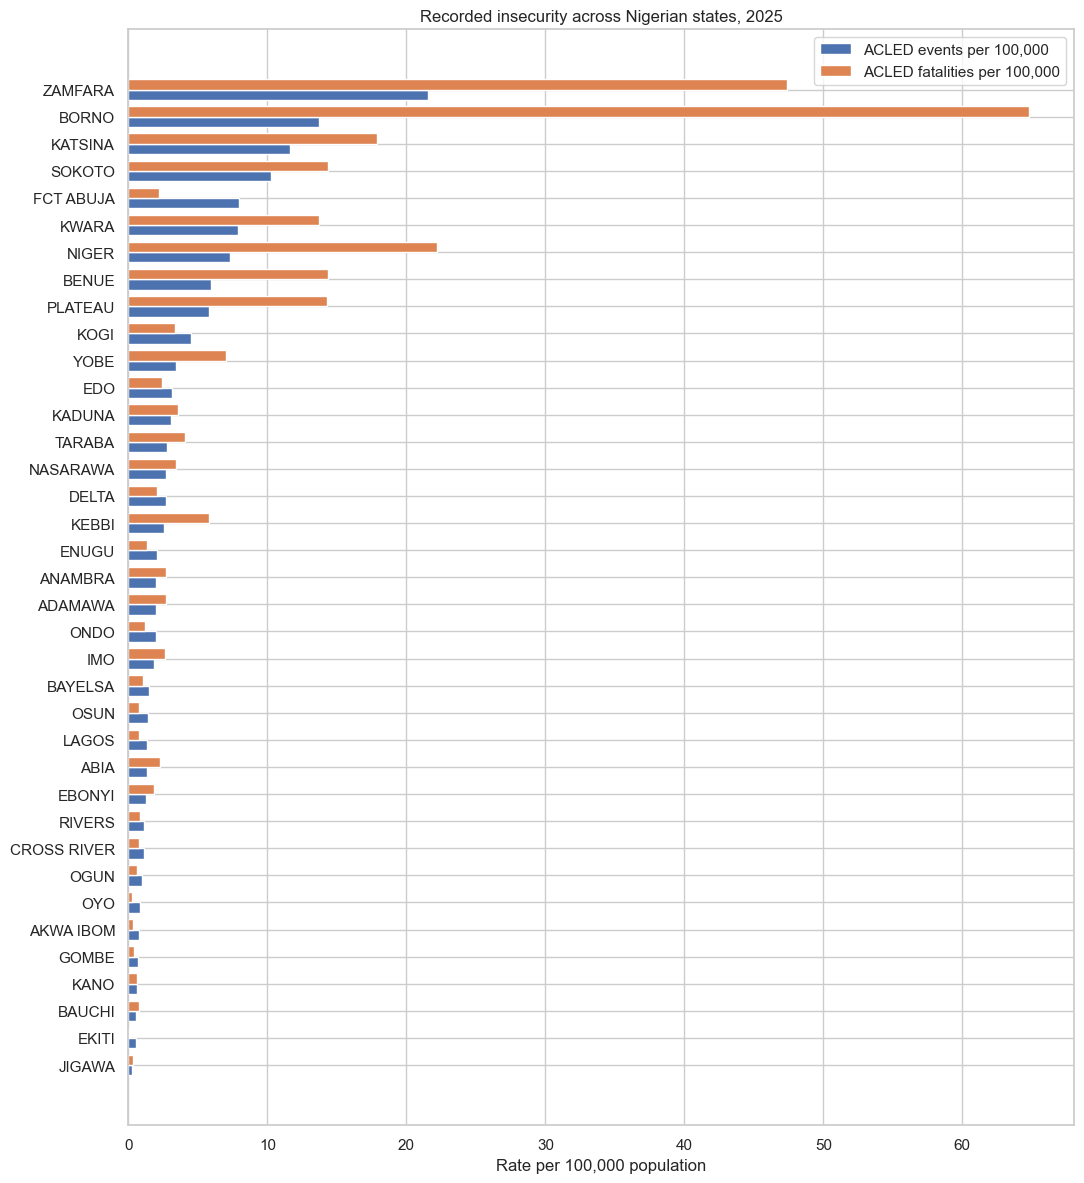

Figure saved to:
C:\Users\user\Desktop\RESEARCH MASTER PACKAGE\peripheral-insecurity-nigeria-Jupyter-Notebook\figures\Figure_1_ACLED_state_rates_2025.png


In [43]:
# ============================================================
# FIGURE 1 — 2025 ACLED EVENT AND FATALITY RATES BY STATE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Sort states by event rate
fig1_data = master_rq4.sort_values(
    "Events_per_100k",
    ascending=True
).copy()

states = fig1_data["State"]
event_rates = fig1_data["Events_per_100k"]
fatality_rates = fig1_data["Fatalities_per_100k"]

y = np.arange(len(states))

fig, ax = plt.subplots(figsize=(11, 12))

height = 0.38

ax.barh(
    y - height/2,
    event_rates,
    height=height,
    label="ACLED events per 100,000"
)

ax.barh(
    y + height/2,
    fatality_rates,
    height=height,
    label="ACLED fatalities per 100,000"
)

ax.set_yticks(y)
ax.set_yticklabels(states)

ax.set_xlabel("Rate per 100,000 population")
ax.set_title(
    "Recorded insecurity across Nigerian states, 2025"
)

ax.legend()

plt.tight_layout()

# Save figure
figures_dir = project_root / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

figure1_path = figures_dir / "Figure_1_ACLED_state_rates_2025.png"
plt.savefig(
    figure1_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure1_path)

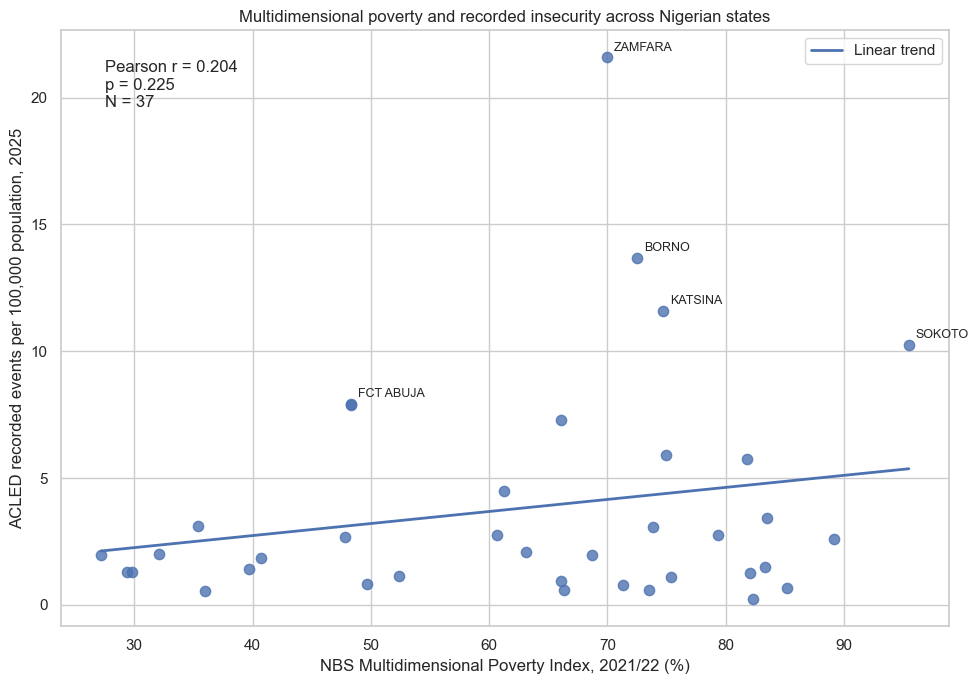

Pearson r: 0.204463
p-value: 0.224791
Figure saved to:
C:\Users\user\Desktop\RESEARCH MASTER PACKAGE\peripheral-insecurity-nigeria-Jupyter-Notebook\figures\Figure_2_MPI_vs_ACLED_event_rate.png


In [44]:
# ============================================================
# FIGURE 2 — MPI AND ACLED EVENT RATE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

fig2_data = master_rq4[
    ["State", "MPI_%", "Events_per_100k"]
].dropna().copy()

x = fig2_data["MPI_%"]
y = fig2_data["Events_per_100k"]

# Pearson correlation
r, p = pearsonr(x, y)

# Linear trend line
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    x,
    y,
    s=55,
    alpha=0.8
)

ax.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Linear trend"
)

# Label selected states
label_states = [
    "ZAMFARA",
    "BORNO",
    "KATSINA",
    "SOKOTO",
    "FCT ABUJA"
]

for _, row in fig2_data[
    fig2_data["State"].isin(label_states)
].iterrows():
    ax.annotate(
        row["State"],
        (row["MPI_%"], row["Events_per_100k"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_xlabel(
    "NBS Multidimensional Poverty Index, 2021/22 (%)"
)

ax.set_ylabel(
    "ACLED recorded events per 100,000 population, 2025"
)

ax.set_title(
    "Multidimensional poverty and recorded insecurity across Nigerian states"
)

ax.text(
    0.05,
    0.95,
    f"Pearson r = {r:.3f}\n"
    f"p = {p:.3f}\n"
    f"N = {len(fig2_data)}",
    transform=ax.transAxes,
    verticalalignment="top"
)

ax.legend()

plt.tight_layout()

figure2_path = (
    figures_dir /
    "Figure_2_MPI_vs_ACLED_event_rate.png"
)

plt.savefig(
    figure2_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Pearson r:", round(r, 6))
print("p-value:", round(p, 6))
print("Figure saved to:")
print(figure2_path)

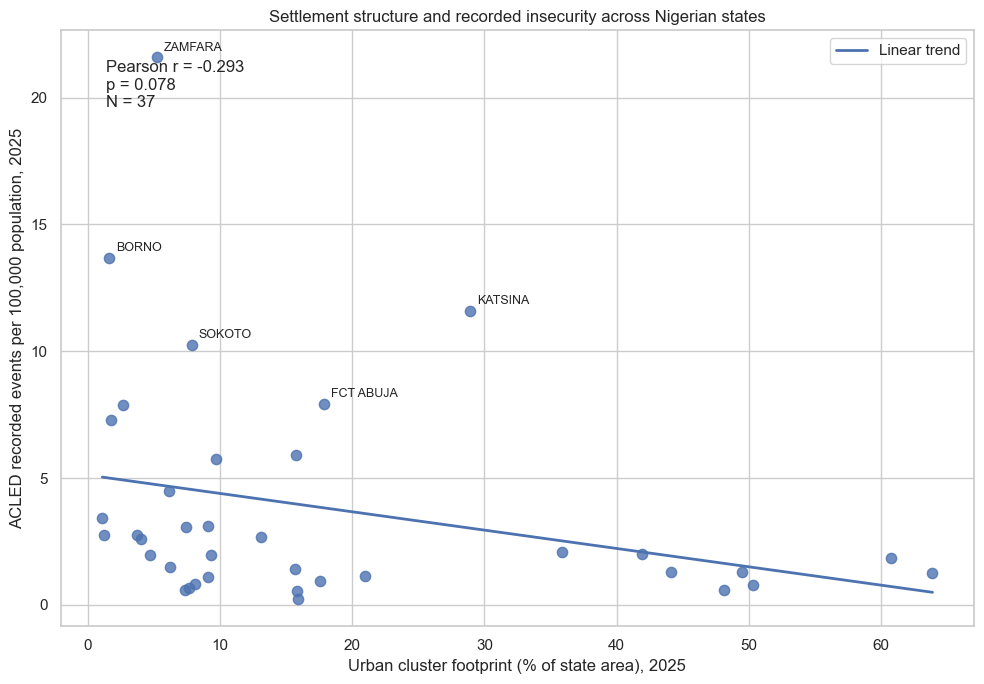

Pearson r: -0.293398
p-value: 0.077996
Figure saved to:
C:\Users\user\Desktop\RESEARCH MASTER PACKAGE\peripheral-insecurity-nigeria-Jupyter-Notebook\figures\Figure_3_Urban_footprint_vs_ACLED_event_rate.png


In [45]:
# ============================================================
# FIGURE 3 — URBAN CLUSTER FOOTPRINT AND ACLED EVENT RATE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

fig3_data = master_rq4[
    ["State", "Urban_Cluster_Footprint_%", "Events_per_100k"]
].dropna().copy()

x = fig3_data["Urban_Cluster_Footprint_%"]
y = fig3_data["Events_per_100k"]

# Pearson correlation
r, p = pearsonr(x, y)

# Linear trend
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    x,
    y,
    s=55,
    alpha=0.8
)

ax.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Linear trend"
)

# Label selected influential/extreme observations
label_states = [
    "ZAMFARA",
    "BORNO",
    "SOKOTO",
    "KATSINA",
    "FCT ABUJA"
]

for _, row in fig3_data[
    fig3_data["State"].isin(label_states)
].iterrows():
    ax.annotate(
        row["State"],
        (row["Urban_Cluster_Footprint_%"], row["Events_per_100k"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_xlabel(
    "Urban cluster footprint (% of state area), 2025"
)

ax.set_ylabel(
    "ACLED recorded events per 100,000 population, 2025"
)

ax.set_title(
    "Settlement structure and recorded insecurity across Nigerian states"
)

ax.text(
    0.05,
    0.95,
    f"Pearson r = {r:.3f}\n"
    f"p = {p:.3f}\n"
    f"N = {len(fig3_data)}",
    transform=ax.transAxes,
    verticalalignment="top"
)

ax.legend()

plt.tight_layout()

figure3_path = (
    figures_dir /
    "Figure_3_Urban_footprint_vs_ACLED_event_rate.png"
)

plt.savefig(
    figure3_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Pearson r:", round(r, 6))
print("p-value:", round(p, 6))
print("Figure saved to:")
print(figure3_path)

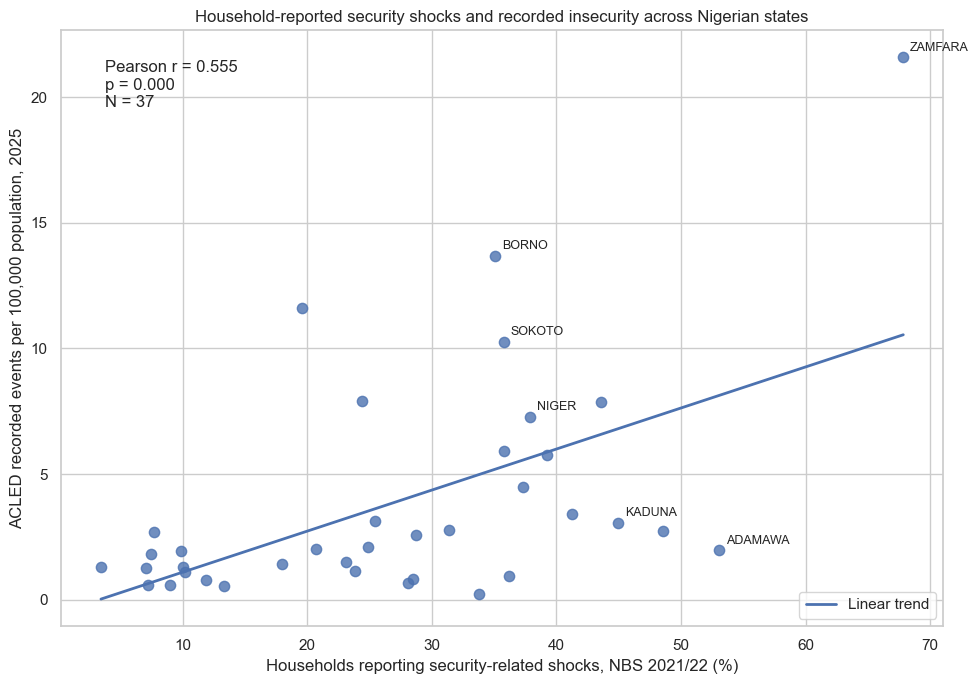

Pearson r: 0.554553
p-value: 0.000369
Figure saved to:
C:\Users\user\Desktop\RESEARCH MASTER PACKAGE\peripheral-insecurity-nigeria-Jupyter-Notebook\figures\Figure_4_NBS_security_shocks_vs_ACLED_event_rate.png


In [46]:
# ============================================================
# FIGURE 4 — NBS HOUSEHOLD SECURITY SHOCKS AND ACLED EVENTS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

fig4_data = master_rq4[
    ["State", "any_security_shock", "Events_per_100k"]
].dropna().copy()

x = fig4_data["any_security_shock"]
y = fig4_data["Events_per_100k"]

# Pearson correlation
r, p = pearsonr(x, y)

# Linear trend
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    x,
    y,
    s=55,
    alpha=0.8
)

ax.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Linear trend"
)

# Label selected states
label_states = [
    "ZAMFARA",
    "ADAMAWA",
    "BORNO",
    "KADUNA",
    "NIGER",
    "SOKOTO"
]

for _, row in fig4_data[
    fig4_data["State"].isin(label_states)
].iterrows():
    ax.annotate(
        row["State"],
        (row["any_security_shock"], row["Events_per_100k"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_xlabel(
    "Households reporting security-related shocks, NBS 2021/22 (%)"
)

ax.set_ylabel(
    "ACLED recorded events per 100,000 population, 2025"
)

ax.set_title(
    "Household-reported security shocks and recorded insecurity across Nigerian states"
)

ax.text(
    0.05,
    0.95,
    f"Pearson r = {r:.3f}\n"
    f"p = {p:.3f}\n"
    f"N = {len(fig4_data)}",
    transform=ax.transAxes,
    verticalalignment="top"
)

ax.legend()

plt.tight_layout()

figure4_path = (
    figures_dir /
    "Figure_4_NBS_security_shocks_vs_ACLED_event_rate.png"
)

plt.savefig(
    figure4_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Pearson r:", round(r, 6))
print("p-value:", round(p, 6))
print("Figure saved to:")
print(figure4_path)

## 7. Generate reproducible results tables

In [47]:
# ============================================================
# MASTER RESULTS TABLE — calculated from analytical objects
# ============================================================

def corr_row(rq, analysis, measure, stat, value, p, n, interpretation):
    return {
        "Research_question": rq, "Analysis": analysis, "Measure": measure,
        "Statistic": stat, "Value": float(value), "P_value": float(p),
        "N": int(n), "Interpretation": interpretation
    }

results = []

# RQ1: ranges derived directly from the integrated dataset.
results.extend([
    {"Research_question": "RQ1: Geographic distribution", "Analysis": "ACLED 2025 state-level rates", "Measure": "Event rate", "Statistic": "Range", "Value": f"{master_rq4['Events_per_100k'].min():.2f}–{master_rq4['Events_per_100k'].max():.2f} per 100,000", "P_value": "", "N": len(master_rq4), "Interpretation": "Recorded insecurity exposure varies substantially across states."},
    {"Research_question": "RQ1: Geographic distribution", "Analysis": "ACLED 2025 state-level rates", "Measure": "Fatality rate", "Statistic": "Range", "Value": f"{master_rq4['Fatalities_per_100k'].min():.2f}–{master_rq4['Fatalities_per_100k'].max():.2f} per 100,000", "P_value": "", "N": len(master_rq4), "Interpretation": "Fatality intensity varies substantially and does not perfectly track event frequency."}
])

# RQ2 and RQ3: derive directly from the correlation table.
lookup = {
    ("MPI_%", "Events_per_100k"): ("RQ2: Socioeconomic deprivation", "MPI vs ACLED event rate", "Weak positive association; statistically uncertain."),
    ("MPI_%", "Fatalities_per_100k"): ("RQ2: Socioeconomic deprivation", "MPI vs ACLED fatality rate", "Weak positive association; statistically uncertain."),
    ("Urban_Cluster_Footprint_%", "Events_per_100k"): ("RQ3: Settlement structure", "Urban footprint vs ACLED event rate", "Negative association; statistically uncertain under Pearson correlation."),
    ("Urban_Cluster_Footprint_%", "Fatalities_per_100k"): ("RQ3: Settlement structure", "Urban footprint vs ACLED fatality rate", "Negative association; statistically uncertain under Pearson correlation.")
}

for _, row in correlations.iterrows():
    rq, measure, interpretation = lookup[(row["X"], row["Y"])]
    results.append(corr_row(rq, "Pearson correlation", measure, "r", row["Pearson_r"], row["Pearson_p"], len(master), interpretation))
    results.append(corr_row(rq, "Spearman correlation", measure, "rho", row["Spearman_r"], row["Spearman_p"], len(master), "Rank-order association; see coefficient and p-value."))

# RQ4 main and Borno sensitivity results.
for _, row in rq4_correlations.iterrows():
    results.append(corr_row("RQ4: Household-reported security", "Pearson correlation", row["Comparison"], "r", row["Pearson_r"], row["Pearson_p"], len(master_rq4), "Moderate positive association."))
    results.append(corr_row("RQ4: Household-reported security", "Spearman correlation", row["Comparison"], "rho", row["Spearman_rho"], row["Spearman_p"], len(master_rq4), "Moderate positive rank-order association."))

for _, row in rq4_borno_sensitivity.iterrows():
    results.append(corr_row("RQ4: Borno sensitivity", "Borno excluded", row["Comparison"], "Pearson r", row["Pearson_r"], row["Pearson_p"], len(rq4_no_borno), "Positive association remains after excluding Borno."))
    results.append(corr_row("RQ4: Borno sensitivity", "Borno excluded", row["Comparison"], "Spearman rho", row["Spearman_rho"], row["Spearman_p"], len(rq4_no_borno), "Positive rank-order association remains."))

master_results = pd.DataFrame(results)
results_path = TABLES_DIR / "Master_Results_Table.csv"
master_results.to_csv(results_path, index=False)

print("Master results table saved:", results_path)
print("Shape:", master_results.shape)
print(master_results.to_string(index=False))

Master results table saved: C:\Users\user\Desktop\RESEARCH MASTER PACKAGE\peripheral-insecurity-nigeria-Jupyter-Notebook\outputs\tables\Master_Results_Table.csv
Shape: (18, 8)
               Research_question                     Analysis                                    Measure    Statistic                  Value   P_value  N                                                                        Interpretation
    RQ1: Geographic distribution ACLED 2025 state-level rates                                 Event rate        Range 0.23–21.58 per 100,000           37                      Recorded insecurity exposure varies substantially across states.
    RQ1: Geographic distribution ACLED 2025 state-level rates                              Fatality rate        Range 0.06–64.80 per 100,000           37 Fatality intensity varies substantially and does not perfectly track event frequency.
  RQ2: Socioeconomic deprivation          Pearson correlation                    MPI vs ACLED event rate

In [48]:
# ============================================================
# RESEARCH QUESTION → EVIDENCE → FINDING → LIMITATION
# ============================================================

synthesis = pd.DataFrame([
    {"Research_question": "RQ1: Geographic distribution", "Evidence": "ACLED 2025 state-level event and fatality rates", "Finding": "Recorded insecurity varies substantially across Nigerian states, and event frequency does not perfectly correspond with fatality intensity.", "Limitation": "ACLED measures recorded events and fatalities rather than total underlying insecurity; the 2025 Nigeria data also underwent later integration of historical local-information-network data to address a documented sourcing gap."},
    {"Research_question": "RQ2: Socioeconomic deprivation", "Evidence": "NBS MPI 2021/22 compared with ACLED 2025 event and fatality rates", "Finding": "The association between multidimensional poverty and recorded insecurity is weak and statistically uncertain at the state level.", "Limitation": "The NBS and ACLED measures refer to different periods, and the analysis is observational and state-level; it cannot establish causation."},
    {"Research_question": "RQ3: Settlement structure", "Evidence": "WorldPop 2025 urban-cluster footprint compared with ACLED 2025 event and fatality rates", "Finding": "States with larger urban-cluster footprints tend to have lower recorded event and fatality rates in the bivariate rank-order analysis, although the relationship is less certain in multivariable analysis.", "Limitation": "Urban-cluster footprint measures settlement area rather than population share, and the WorldPop entity layers are not mutually exclusive."},
    {"Research_question": "RQ4: Household-reported security experience", "Evidence": "NBS 2021/22 household-reported security-related shocks compared with ACLED 2025 event and fatality rates", "Finding": "Household-reported security-related shocks show a moderate positive association with both recorded event and fatality rates. The association remains after excluding Borno.", "Limitation": "The NBS survey predates the ACLED observation year and uses a different measurement system, so the result should be interpreted as complementary spatial evidence rather than temporal validation."},
    {"Research_question": "RQ5: Security planning implications", "Evidence": "Combined findings from ACLED, NBS MPI, NBS household security data and WorldPop settlement data", "Finding": "The analysis suggests that understanding insecurity requires attention to geographic variation, settlement structure and household-reported security experiences alongside conventional event counts.", "Limitation": "The study is exploratory and state-level; it does not establish causal mechanisms or directly evaluate the effectiveness of particular security interventions."}
])

synthesis_path = TABLES_DIR / "Research_Question_Evidence_Synthesis.csv"
synthesis.to_csv(synthesis_path, index=False)
print("Research synthesis table saved:", synthesis_path)
print(synthesis.to_string(index=False))

Research synthesis table saved: C:\Users\user\Desktop\RESEARCH MASTER PACKAGE\peripheral-insecurity-nigeria-Jupyter-Notebook\outputs\tables\Research_Question_Evidence_Synthesis.csv
                          Research_question                                                                                                 Evidence                                                                                                                                                                                                     Finding                                                                                                                                                                                                                       Limitation
               RQ1: Geographic distribution                                                          ACLED 2025 state-level event and fatality rates                                                                 Recorded insecurity varies s

## 8. Final reproducibility checks

The final checks should confirm that the integrated analytical dataset contains 37 state/FCT observations, that no state is missing after RQ4 integration, and that the main result tables are generated from calculated objects rather than manually entered statistics.

In [49]:
# Final structural checks
assert master.shape[0] == 37, f"Expected 37 state/FCT units, found {master.shape[0]}"
assert master_rq4.shape[0] == 37, f"Expected 37 integrated units, found {master_rq4.shape[0]}"
assert master_rq4["any_security_shock"].isna().sum() == 0, "Missing RQ4 values remain after integration."
assert set(master["State"]) == set(master_rq4["State"]), "State coverage changed during RQ4 integration."
assert results_path.exists(), "Master results table was not created."
assert synthesis_path.exists(), "Research synthesis table was not created."

print("All final reproducibility checks passed.")
print("State/FCT units:", master_rq4.shape[0])
print("Missing RQ4 values:", master_rq4["any_security_shock"].isna().sum())
print("Master results rows:", len(master_results))
print("Synthesis rows:", len(synthesis))

All final reproducibility checks passed.
State/FCT units: 37
Missing RQ4 values: 0
Master results rows: 18
Synthesis rows: 5
